# 10단계 · 멀티종목 포트폴리오 백테스팅

## 09번 전략을 여러 종목에 동시 적용

09번(단일 종목 + 부분 매수/매도)을 **5개 섹터 대표주**로 확장한다.  
각 종목의 ADX 국면이 달라 동시에 모두 하락장에 빠질 확률이 낮아진다 → **분산투자 효과**

```
09번:  삼성전자 1종목  →  size_series (1D)  →  단일 백테스트
10번:  5종목 포트폴리오 →  size_df (5컬럼)  →  공유 현금 포트폴리오
```

## 포트폴리오 구성 종목 (WICS 섹터 대표주)

| 종목 | 코드 | WICS 섹터 |
|------|------|----------|
| 삼성전자 | 005930.KS | IT (반도체) |
| SK하이닉스 | 000660.KS | IT (메모리) |
| NAVER | 035420.KS | 경기관련소비재 (인터넷) |
| 현대차 | 005380.KS | 경기관련소비재 (자동차) |
| POSCO홀딩스 | 005490.KS | 소재 (철강) |

## 핵심 설계 원칙

```
종목별 최대 비중 = 1 / N = 20%  (N=5)
실제 진입 비중  = ADX 비례 × (1/N)  →  최대 20%, 최소 6%

공유 현금(cash_sharing=True): 5종목이 하나의 현금 풀을 나눠 씀
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from vbt_backtest.strategies import partial_sizing_strategy

# ── 설정 ────────────────────────────────────────────────────────────────────
START    = '2019-01-01'
END      = '2024-12-31'
FEES     = 0.0015
SLIPPAGE = 0.001

ADX_THRESHOLD = 25.0   # 09번 기본값과 동일
ADX_SCALE     = 30.0

TICKERS = {
    '삼성전자':    '005930.KS',
    'SK하이닉스':  '000660.KS',
    'NAVER':      '035420.KS',
    '현대차':      '005380.KS',
    'POSCO홀딩스': '005490.KS',
}
NAMES = list(TICKERS.keys())
CODES = list(TICKERS.values())
N     = len(TICKERS)

print(f'포트폴리오 종목 수: {N}개')
print(f'종목별 최대 비중: {1/N:.0%}')
print(f'ADX threshold={ADX_THRESHOLD}, scale={ADX_SCALE}')

포트폴리오 종목 수: 5개
종목별 최대 비중: 20%
ADX threshold=25.0, scale=30.0


---
## 1단계 · 5종목 데이터 로드

In [2]:
df_raw = yf.download(CODES, start=START, end=END, auto_adjust=True, progress=False)

name_map = {v: k for k, v in TICKERS.items()}

close_df  = df_raw['Close'].rename(columns=name_map)
high_df   = df_raw['High'].rename(columns=name_map)
low_df    = df_raw['Low'].rename(columns=name_map)
volume_df = df_raw['Volume'].rename(columns=name_map)

# 결측값 처리: 공휴일·서킷브레이커 등 forward fill
close_df  = close_df[NAMES].ffill().dropna()
high_df   = high_df[NAMES].ffill().dropna()
low_df    = low_df[NAMES].ffill().dropna()
volume_df = volume_df[NAMES].fillna(0)

print(f'기간  : {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'거래일: {len(close_df)}일')
print()

# 종목별 가격 변화
print('=== 종목별 시작가 → 종가 (수익률) ===')
for name in NAMES:
    s = close_df[name].iloc[0]
    e = close_df[name].iloc[-1]
    print(f'  {name:10s}: {s:>8,.0f}원 → {e:>8,.0f}원  ({(e/s-1):.1%})')

기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일

=== 종목별 시작가 → 종가 (수익률) ===
  삼성전자      :   32,297원 →   51,969원  (60.9%)
  SK하이닉스    :   56,288원 →  171,782원  (205.2%)
  NAVER     :  114,435원 →  195,872원  (71.2%)
  현대차       :   88,118원 →  197,933원  (124.6%)
  POSCO홀딩스  :  182,284원 →  243,078원  (33.4%)


---
## 2단계 · 종목별 신호 생성 → size_df 구성

각 종목에 09번 전략을 독립적으로 적용하고,  
포트폴리오 레벨 비중 `(1/N)`을 곱해 공유 현금 기준으로 변환한다.

```
종목 개별 ADX 비례값: 0.30 ~ 1.00
포트폴리오 비중:      0.06 ~ 0.20  (× 1/5)
```

In [3]:
size_df = pd.DataFrame(np.nan, index=close_df.index, columns=NAMES)
signal_counts = {}

for name in NAMES:
    _, _, size_s, detail = partial_sizing_strategy.make_signals(
        close_df[name], high_df[name], low_df[name], volume_df[name],
        adx_threshold=ADX_THRESHOLD,
        adx_scale=ADX_SCALE,
    )
    # 포트폴리오 레벨 비중 = 개별 비중 / N
    size_df[name] = size_s / N

    entries = detail['strong_entries'] | detail['weak_entries'] | detail['range_entries']
    signal_counts[name] = {
        '진입 횟수': int(entries.sum()),
        '약세 부분청산': int(detail['weak_bear_start'].sum()),
        '강세 전량청산': int(detail['strong_bear_start'].sum()),
    }

df_signals = pd.DataFrame(signal_counts).T
print('=== 종목별 신호 횟수 ===')
print(df_signals.to_string())
print()
print(f'size_df 비-NaN 값 범위: {size_df.stack().min():.3f} ~ {size_df.stack().max():.3f}')

=== 종목별 신호 횟수 ===
          진입 횟수  약세 부분청산  강세 전량청산
삼성전자         43        3        6
SK하이닉스       46        5        6
NAVER        43       10       10
현대차          44       11        8
POSCO홀딩스     40       10       10

size_df 비-NaN 값 범위: 0.000 ~ 0.195


---
## 3단계 · 포트폴리오 백테스팅 실행

**`group_by=True` + `cash_sharing=True`**:  
5종목이 하나의 현금 풀을 공유 → 진정한 포트폴리오 시뮬레이션

In [4]:
# ── 09번 포트폴리오 (부분 매수/매도 + 공유 현금) ──────────────────────────
pf_09 = vbt.Portfolio.from_orders(
    close_df,
    size=size_df,
    size_type='targetpercent',
    group_by=True,
    cash_sharing=True,
    fees=FEES,
    slippage=SLIPPAGE,
    freq='D',
)

# ── Buy & Hold 균등 비중 (첫날 각 20% 매수 후 보유) ───────────────────────
bh_size_df = pd.DataFrame(np.nan, index=close_df.index, columns=NAMES)
bh_size_df.iloc[0] = 1.0 / N   # 첫날 균등 배분

pf_bh = vbt.Portfolio.from_orders(
    close_df,
    size=bh_size_df,
    size_type='targetpercent',
    group_by=True,
    cash_sharing=True,
    fees=FEES,
    slippage=SLIPPAGE,
    freq='D',
)

# ── 삼성전자 단독 B&H (단순 비교용) ────────────────────────────────────────
bh_ss_e = pd.Series(False, index=close_df.index); bh_ss_e.iloc[0] = True
bh_ss_x = pd.Series(False, index=close_df.index); bh_ss_x.iloc[-1] = True
pf_bh_ss = vbt.Portfolio.from_signals(
    close_df['삼성전자'], bh_ss_e, bh_ss_x,
    fees=FEES, slippage=SLIPPAGE, freq='D'
)

val_09 = pf_09.value()
val_bh = pf_bh.value()

print(f'09번 포트폴리오 총수익률: {(val_09.iloc[-1]/val_09.iloc[0]-1):.2%}')
print(f'BH 균등포트폴리오 총수익률: {(val_bh.iloc[-1]/val_bh.iloc[0]-1):.2%}')
print(f'삼성전자 단독 BH 총수익률: {pf_bh_ss.total_return():.2%}')

09번 포트폴리오 총수익률: -1.30%
BH 균등포트폴리오 총수익률: 99.21%
삼성전자 단독 BH 총수익률: 60.11%


---
## 4단계 · 자산 곡선 비교

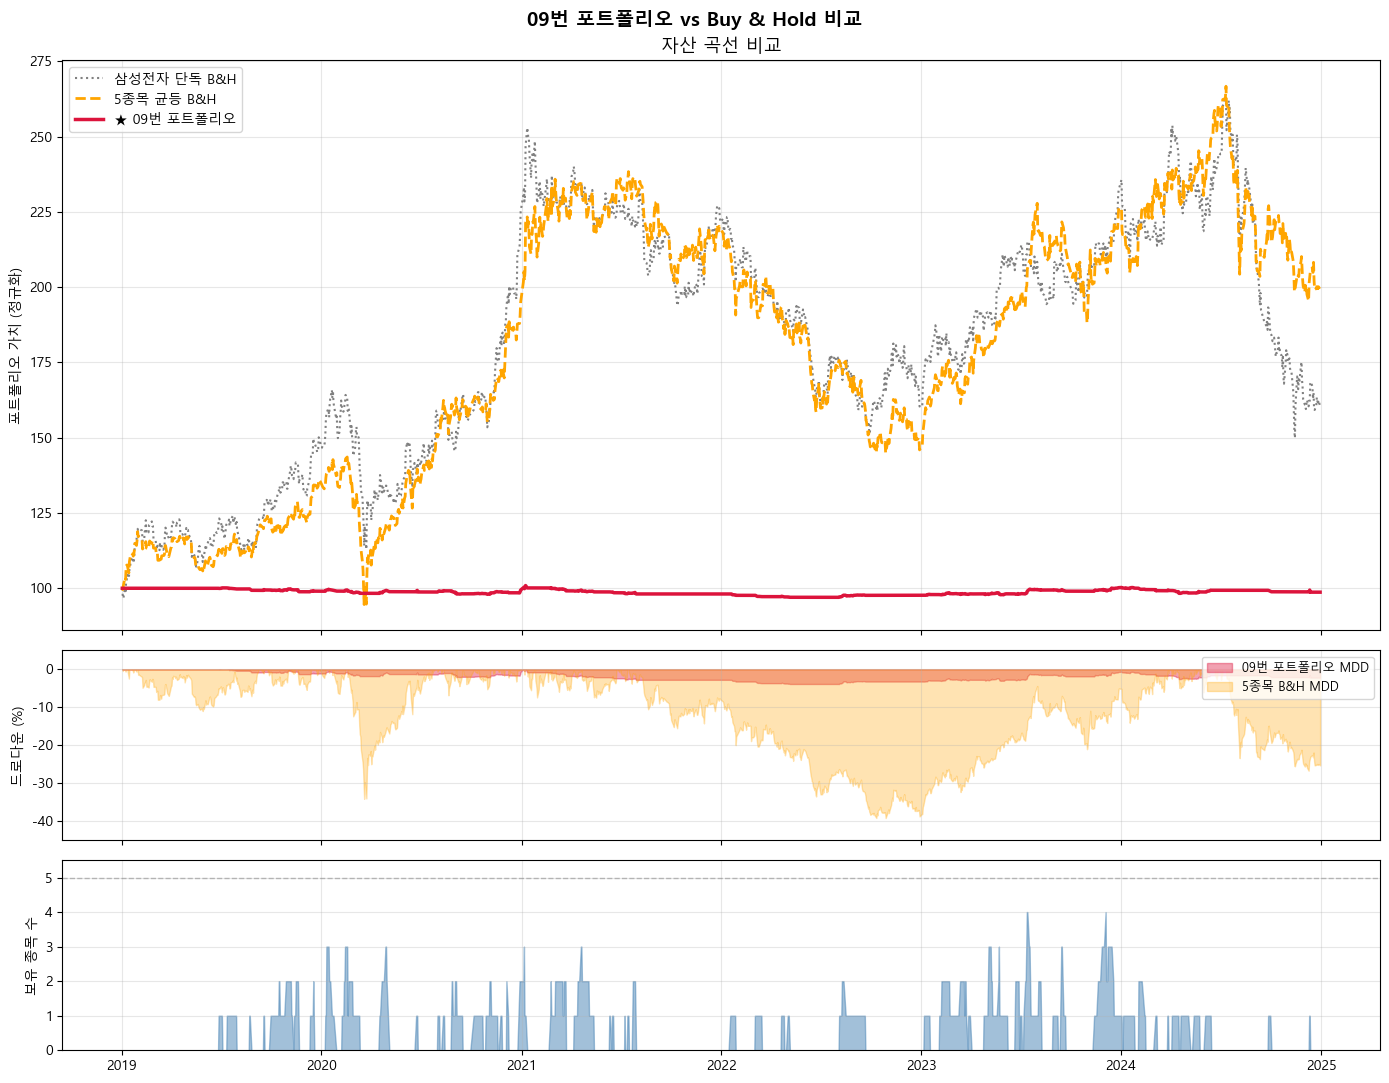

In [5]:
init = val_09.iloc[0]
bh_norm    = val_bh / val_bh.iloc[0] * init
bh_ss_norm = pf_bh_ss.value() / pf_bh_ss.value().iloc[0] * init

# group_by=False → 종목별 개별 자산 가치 DataFrame 반환
asset_vals = pf_09.asset_value(group_by=False)
asset_vals.columns = NAMES

fig, axes = plt.subplots(3, 1, figsize=(14, 11),
                          gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)

# ① 자산 곡선
axes[0].plot(bh_ss_norm, color='gray',     lw=1.5, ls=':', label='삼성전자 단독 B&H')
axes[0].plot(bh_norm,    color='orange',   lw=2.0, ls='--', label='5종목 균등 B&H')
axes[0].plot(val_09,     color='crimson',  lw=2.5, ls='-',  label='★ 09번 포트폴리오')
axes[0].set_title('자산 곡선 비교', fontsize=13)
axes[0].set_ylabel('포트폴리오 가치 (정규화)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ② 드로다운
dd09 = (val_09 / val_09.cummax() - 1) * 100
dd_bh = (bh_norm / bh_norm.cummax() - 1) * 100
axes[1].fill_between(dd09.index,  0, dd09,  color='crimson', alpha=0.4, label='09번 포트폴리오 MDD')
axes[1].fill_between(dd_bh.index, 0, dd_bh, color='orange',  alpha=0.3, label='5종목 B&H MDD')
axes[1].set_ylabel('드로다운 (%)')
axes[1].set_ylim(min(dd09.min(), dd_bh.min()) * 1.15, 5)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ③ 동시 보유 종목 수
n_held = (asset_vals > 0.5).sum(axis=1)
axes[2].fill_between(n_held.index, 0, n_held, color='steelblue', alpha=0.5)
axes[2].set_ylabel('보유 종목 수')
axes[2].set_ylim(0, N + 0.5)
axes[2].set_yticks(range(N + 1))
axes[2].axhline(N, color='gray', lw=1, ls='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.suptitle('09번 포트폴리오 vs Buy & Hold 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5단계 · 성과 비교 테이블

In [6]:
n_years = (close_df.index[-1] - close_df.index[0]).days / 365.25

def metrics(equity: pd.Series, label: str) -> dict:
    total  = equity.iloc[-1] / equity.iloc[0] - 1
    cagr   = (equity.iloc[-1] / equity.iloc[0]) ** (1 / n_years) - 1
    dr     = equity.pct_change().dropna()
    vol    = dr.std() * np.sqrt(252)
    sharpe = dr.mean() / dr.std() * np.sqrt(252) if dr.std() > 0 else np.nan
    mdd    = (equity / equity.cummax() - 1).min()
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan
    return {
        '전략':          label,
        '총 수익률':     f'{total:.2%}',
        'CAGR':         f'{cagr:.2%}',
        '연간 변동성':   f'{vol:.2%}',
        '샤프비율':      f'{sharpe:.2f}',
        'MDD':          f'{mdd:.2%}',
        'Calmar':        f'{calmar:.2f}' if not np.isnan(calmar) else 'N/A',
    }

rows = [
    metrics(bh_ss_norm,                         '삼성전자 단독 B&H'),
    metrics(bh_norm,                             '5종목 균등 B&H'),
    metrics(val_09,                              '★ 09번 포트폴리오'),
]

# 종목별 단독 B&H도 추가
for name in NAMES:
    s = close_df[name]
    rows.append(metrics(s / s.iloc[0] * init, f'  {name} 단독 B&H'))

df_perf = pd.DataFrame(rows).set_index('전략')
print(f'=== 성과 비교 ({close_df.index[0].date()} ~ {close_df.index[-1].date()}) ===')
print(df_perf.to_string())

=== 성과 비교 (2019-01-02 ~ 2024-12-30) ===
                     총 수익률    CAGR  연간 변동성   샤프비율      MDD Calmar
전략                                                               
삼성전자 단독 B&H         60.51%   8.22%  26.27%   0.44  -42.85%   0.19
5종목 균등 B&H          99.21%  12.19%  24.03%   0.61  -39.20%   0.31
★ 09번 포트폴리오         -1.30%  -0.22%   1.47%  -0.14   -3.88%  -0.06
  삼성전자 단독 B&H       60.91%   8.26%  26.27%   0.44  -42.85%   0.19
  SK하이닉스 단독 B&H    205.19%  20.46%  38.86%   0.68  -48.20%   0.42
  NAVER 단독 B&H      71.16%   9.38%  35.04%   0.44  -65.45%   0.14
  현대차 단독 B&H       124.62%  14.46%  34.47%   0.57  -52.59%   0.27
  POSCO홀딩스 단독 B&H   33.35%   4.92%  37.24%   0.32  -60.31%   0.08


---
## 6단계 · 포지션 히트맵 (날짜 × 종목)

In [ ]:
# 실제 포트폴리오 비중 (asset_value / total_value) — asset_vals는 앞 셀에서 생성됨
weights = asset_vals.div(val_09, axis=0).clip(0, 1) * 100   # %

# 월별 평균으로 압축 (일별은 너무 조밀) — 'M' = 구버전 pandas month-end alias
weights_m = weights.resample('M').mean()

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    weights_m.T,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=20,
    linewidths=0.3,
    cbar_kws={'label': '보유 비중 (%)', 'shrink': 0.8},
    xticklabels=[d.strftime('%y.%m') for d in weights_m.index],
)
ax.set_title('월별 종목 보유 비중 히트맵 (빨강=0%, 초록=20%)', fontsize=12)
ax.set_xlabel('날짜')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print('\n=== 종목별 평균 포지션 비중 ===')
avg_w = weights.mean()
for name in NAMES:
    print(f'  {name:10s}: {avg_w[name]:.1f}%  (최대 {weights[name].max():.1f}%)')

---
## 7단계 · 종목별 수익 기여도 분석

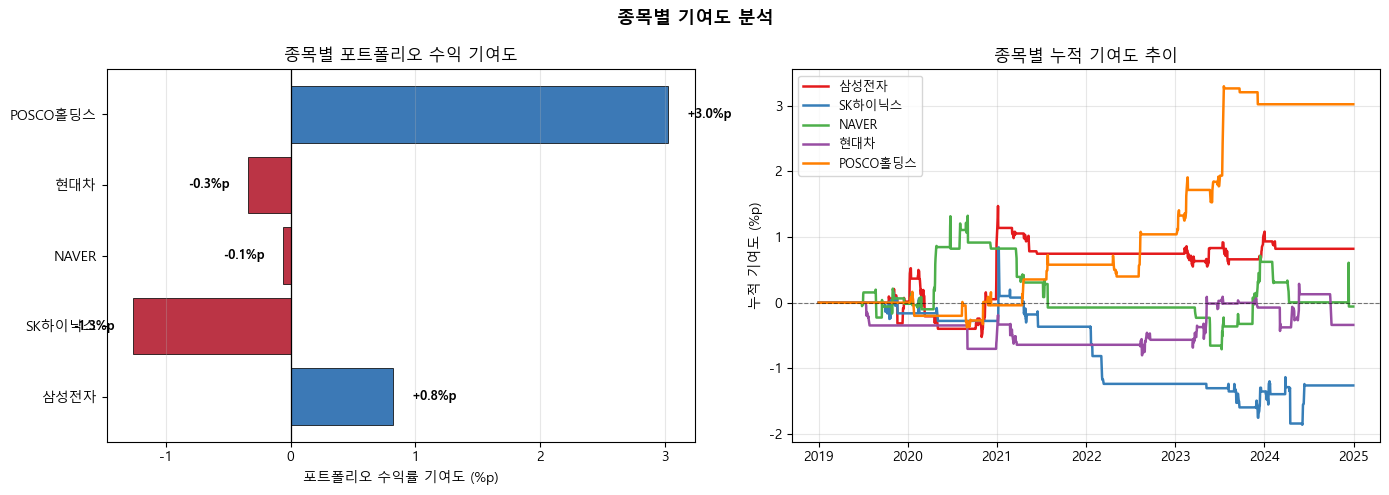


=== 종목별 기여도 순위 ===
  POSCO홀딩스  : +3.02%p
  삼성전자      : +0.82%p
  NAVER     : -0.06%p
  현대차       : -0.34%p
  SK하이닉스    : -1.26%p


In [8]:
# 기여도 = 포지션 비중(t-1) × 종목 일간 수익률(t) 의 누적합
# → 포지션을 들고 있던 날에 그 종목이 오른 만큼만 포트폴리오에 기여
stock_rets    = close_df.pct_change().fillna(0)
pos_w         = asset_vals.div(val_09, axis=0).fillna(0).clip(0, 1)   # 0~1 비중
daily_contrib = pos_w.shift(1).fillna(0) * stock_rets                  # 일별 기여
total_contrib = daily_contrib.sum() * 100                              # 전체 기간 합계 (%p)
cum_contrib   = daily_contrib.cumsum() * 100                           # 누적 시계열

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 최종 기여도 바차트
colors_c = ['#2166ac' if v >= 0 else '#b2182b' for v in total_contrib]
bars = axes[0].barh(NAMES, total_contrib, color=colors_c,
                    edgecolor='black', linewidth=0.6, alpha=0.88)
axes[0].axvline(0, color='black', linewidth=0.9)
axes[0].set_xlabel('포트폴리오 수익률 기여도 (%p)')
axes[0].set_title('종목별 포트폴리오 수익 기여도', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, total_contrib):
    xpos = val + 0.15 if val >= 0 else val - 0.15
    ha   = 'left' if val >= 0 else 'right'
    axes[0].text(xpos, bar.get_y() + bar.get_height()/2,
                 f'{val:+.1f}%p', va='center', ha=ha, fontsize=9, fontweight='bold')

# 오른쪽: 기여도 누적 시계열
colors_line = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for name, color in zip(NAMES, colors_line):
    axes[1].plot(cum_contrib[name], lw=1.8, color=color, label=name)
axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
axes[1].set_title('종목별 누적 기여도 추이', fontsize=12)
axes[1].set_ylabel('누적 기여도 (%p)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('종목별 기여도 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 종목별 기여도 순위 ===')
for name in total_contrib.sort_values(ascending=False).index:
    sign = '+' if total_contrib[name] >= 0 else ''
    print(f'  {name:10s}: {total_contrib[name]:+.2f}%p')

---
## 8단계 · 분산투자 효과 분석

**분산투자 효과**: 종목 간 상관관계가 낮을수록 포트폴리오 변동성이 개별 종목보다 낮아진다.

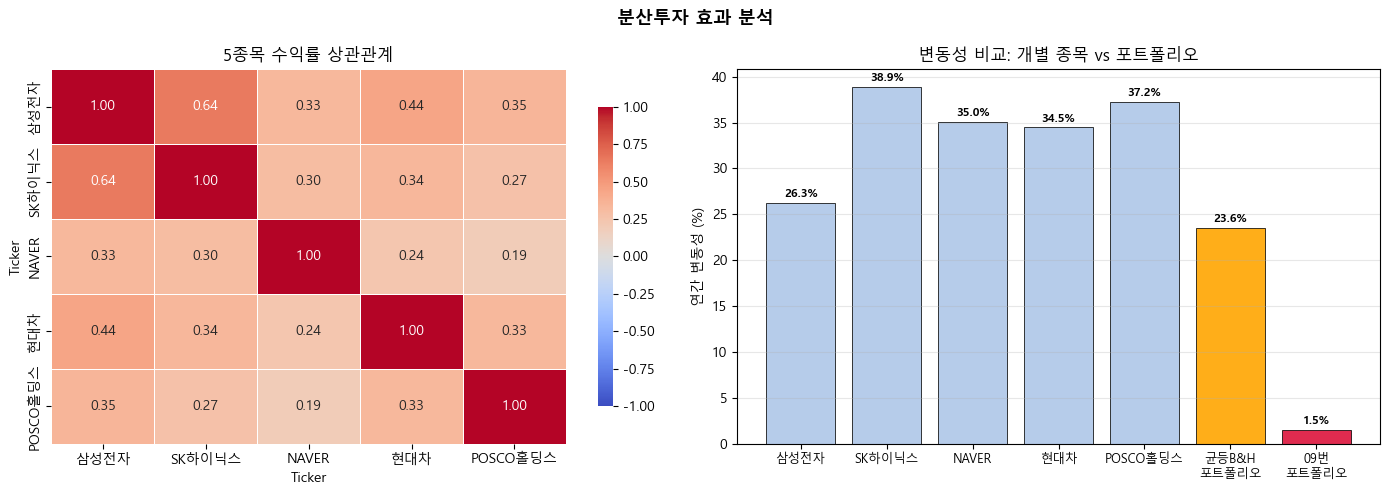


=== 분산투자 효과 ===
개별 종목 평균 변동성: 34.4%
균등 B&H 포트폴리오:  23.6%  (개별 대비 69%)
09번 포트폴리오:       1.5%  (개별 대비 4%)


In [9]:
# 일간 수익률
returns_df = close_df.pct_change().dropna()
corr_mat   = returns_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 상관관계 히트맵
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat,
    ax=axes[0],
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
axes[0].set_title('5종목 수익률 상관관계', fontsize=12)

# 오른쪽: 개별 종목 vs 포트폴리오 연간 변동성 비교
vols = returns_df.std() * np.sqrt(252) * 100   # 연간 변동성 %
pf_vol = returns_df.mean(axis=1).std() * np.sqrt(252) * 100
pf09_vol = val_09.pct_change().dropna().std() * np.sqrt(252) * 100

vol_data  = list(vols[NAMES]) + [pf_vol, pf09_vol]
vol_labels = NAMES + ['균등B&H\n포트폴리오', '09번\n포트폴리오']
colors_vol = ['#aec7e8'] * N + ['orange', 'crimson']

bars = axes[1].bar(range(len(vol_data)), vol_data, color=colors_vol,
                   edgecolor='black', linewidth=0.6, alpha=0.9)
axes[1].set_xticks(range(len(vol_data)))
axes[1].set_xticklabels(vol_labels, fontsize=9)
axes[1].set_ylabel('연간 변동성 (%)')
axes[1].set_title('변동성 비교: 개별 종목 vs 포트폴리오', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, vol_data):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.suptitle('분산투자 효과 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 분산투자 효과 ===')
avg_stock_vol = vols.mean()
print(f'개별 종목 평균 변동성: {avg_stock_vol:.1f}%')
print(f'균등 B&H 포트폴리오:  {pf_vol:.1f}%  (개별 대비 {pf_vol/avg_stock_vol:.0%})')
print(f'09번 포트폴리오:       {pf09_vol:.1f}%  (개별 대비 {pf09_vol/avg_stock_vol:.0%})')

---
## 9단계 · 연도별 성과 (캘린더 뷰)

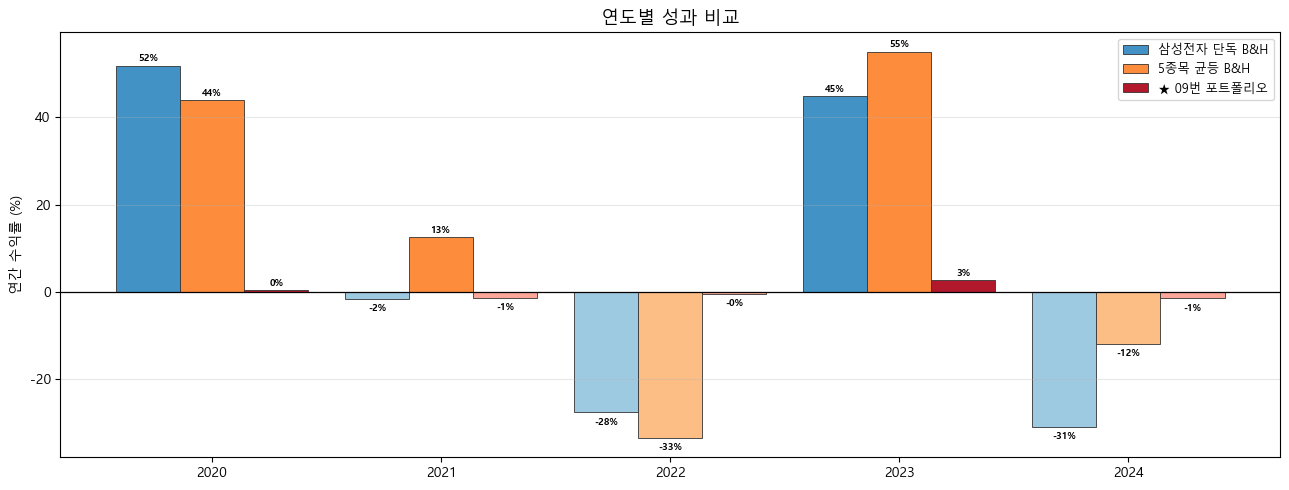

In [11]:
def yearly_returns(equity: pd.Series) -> pd.Series:
    return equity.resample('A').last().pct_change().dropna()

yr_09 = yearly_returns(val_09)
yr_bh = yearly_returns(bh_norm)
yr_ss = yearly_returns(bh_ss_norm)

years = [str(y.year) for y in yr_09.index]
x = np.arange(len(years))
w = 0.28

fig, ax = plt.subplots(figsize=(13, 5))

C_SS  = ['#4292c6' if v >= 0 else '#9ecae1' for v in yr_ss]
C_BH  = ['#fd8d3c' if v >= 0 else '#fdbe85' for v in yr_bh]
C_09  = ['#b2182b' if v >= 0 else '#fca69a' for v in yr_09]

b1 = ax.bar(x - w,   yr_ss * 100, w, color=C_SS, edgecolor='#333', lw=0.6, label='삼성전자 단독 B&H')
b2 = ax.bar(x,       yr_bh * 100, w, color=C_BH, edgecolor='#333', lw=0.6, label='5종목 균등 B&H')
b3 = ax.bar(x + w,   yr_09 * 100, w, color=C_09, edgecolor='#333', lw=0.6, label='★ 09번 포트폴리오')

ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=10)
ax.set_ylabel('연간 수익률 (%)')
ax.set_title('연도별 성과 비교', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

for bars, vals in [(b1, yr_ss), (b2, yr_bh), (b3, yr_09)]:
    for bar, val in zip(bars, vals):
        v = val * 100
        yp = v + 0.5 if v >= 0 else v - 1.2
        ax.text(bar.get_x() + bar.get_width()/2, yp,
                f'{v:.0f}%', ha='center',
                va='bottom' if v >= 0 else 'top',
                fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 정리

### 단일 종목 vs 멀티 포트폴리오

| 구분 | 09번 (삼성 단독) | 10번 (5종목 포트폴리오) |
|------|----------------|---------------------|
| 진입 기회 | 삼성전자 ADX만 의존 | 5종목 중 하나라도 신호 → 진입 |
| 하락 위험 | 삼성 하락 = 전체 손실 | 5종목 동시 하락 가능성 낮음 |
| 변동성 | 개별 종목 변동성 | 분산 효과로 낮아짐 |
| 복잡도 | 단순 | size_df 관리 필요 |

### 분산투자 핵심 공식

```
포트폴리오 변동성 < 개별 종목 평균 변동성
  → 상관관계가 1보다 낮을 때 항상 성립
  → 상관관계가 낮을수록 효과 큼
```

### 다음 개선 방향

```
1. 종목별 Walk-Forward 최적화: 각 종목에 최적 (threshold, scale) 독립 탐색
2. 동적 비중 조절: 변동성 역비례 비중 (낮은 변동성 종목 → 더 많은 비중)
3. 섹터 확장: 5개 → WICS 전체 섹터 대표주 (금융/에너지/헬스케어 추가)
4. 리밸런싱: 월별/분기별 비중 재조정
5. 롱숏: STRONG_BEAR 국면 종목 공매도 (인버스 ETF 활용)
```